In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
import seaborn as sns
from scipy.stats import pearsonr 
from scipy.stats import shapiro 
from scipy.stats import linregress
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  
from matplotlib.patches import Rectangle


C:\Users\TomAH\anaconda3\envs\new_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def select_by_lonlat(ds, lon_target, lat_target):
    lat = ds['gphit'].values
    lon = ds['glamt'].values
    distance = np.sqrt((lat - lat_target)**2 + (lon - lon_target)**2)
    y_idx, x_idx = np.unravel_index(np.argmin(distance), distance.shape)
    print('x index =', x_idx)
    print('y index =', y_idx)
    return (y_idx, x_idx)


In [14]:
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13

In [4]:
# Open model and config files

catalog = OceanDataCatalog(catalog_name='noc-model-stac')
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1_annual = catalog.open_dataset(id=catalog.Items[2].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')

catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets_annual = {'parent': {'domain': config, 'gridT': ds1_annual}}
dt_global_annual = NEMODataTree.from_datasets(datasets = datasets_annual)

# Clip to North Atlantic 
bbox = (-85.0, 0.0, 0.0, 80.0)
dt_annual = dt_global_annual.clip_grid(grid='/gridT', bbox=bbox)

# Convert to datasets
ds_annual = (dt_annual['/gridT']).dataset


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [8]:
ds_annual['somxl010'].to_netcdf('MLD_ts_0.25.nc')

In [4]:
salinity = xr.open_dataset('salinity_ts_0.25.nc')
amplitude = xr.open_dataset('amplitude_ts_0.25.nc')
MLD = xr.open_dataset('MLD_ts_0.25.nc')

In [ ]:
## CORRELATION COEFFICIENT - MLD and Amplitude 

ny, nx = amplitude.sizes['j'], amplitude.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

print('starting loop')
for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude.isel(j=y_idx, i=x_idx)['tos_con'].values
        MLD_ts = MLD.isel(j=y_idx, i=x_idx)['somxl010'].values
        try:
            r, p = pearsonr(MLD_ts, amp_ts)
            r_data[y_idx, x_idx] = r
            p_data[y_idx, x_idx] = p
        except:
            r_data[y_idx, x_idx] = np.nan
            p_data[y_idx, x_idx] = np.nan
    print(y_idx)

## Converting to dataarray

r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='correlation',
        attrs={'description': 'Correlation coefficient between MLD and amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'P-value for correlation coefficient between MLD and amplitude'})

## Saving correlation coefficient and p-value 

r_da.to_netcdf('Amp_MLD_pearsons.nc')
pval_da.to_netcdf('Amp_MLD_pearsons_pval.nc')

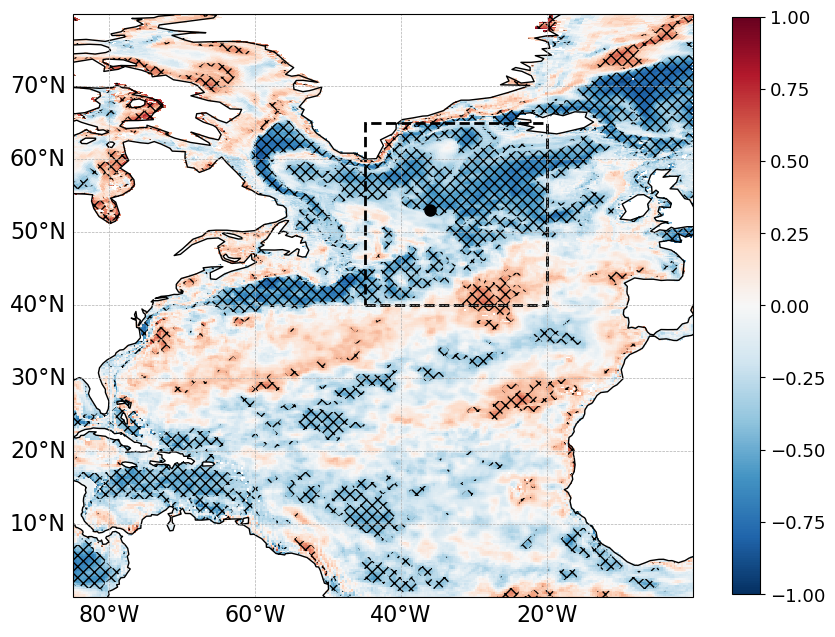

In [15]:
## Start from here in future 

r_da = (xr.open_dataset('Amp_MLD_pearsons.nc'))['correlation']
pval_da = (xr.open_dataset('Amp_MLD_pearsons_pval.nc'))['p-value']

 
sig_mask = pval_da < 0.05
fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -1, vmax = 1)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
# title = ax.set_title('Pearsons correlation coefficient: SST Amplitude and Mixed Layer Depth')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

In [ ]:
## REGRESSION COEFFICIENT - MLD and Amplitude 

ny, nx = amplitude.sizes['j'], amplitude.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

print('starting loop')
for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude.isel(j=y_idx, i=x_idx)['tos_con'].values
        MLD_ts = MLD.isel(j=y_idx, i=x_idx)['somxl010'].values
        if np.isnan(amp_ts).all():
            continue
        results = linregress(MLD_ts, amp_ts) 
        r_data[y_idx, x_idx] = results.slope
        p_data[y_idx, x_idx] = results.pvalue
    print(y_idx)

## Converting to dataarray

r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='correlation',
        attrs={'description': 'Slope of regression of seasonal cycle amplitude on MLD'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'P-value for slope of regression of seasonal cycle amplitude on MLD'})

## Saving coefficient and p-value 

r_da.to_netcdf('Amp_MLD_regression.nc')
pval_da.to_netcdf('Amp_MLD_regression_pval.nc')

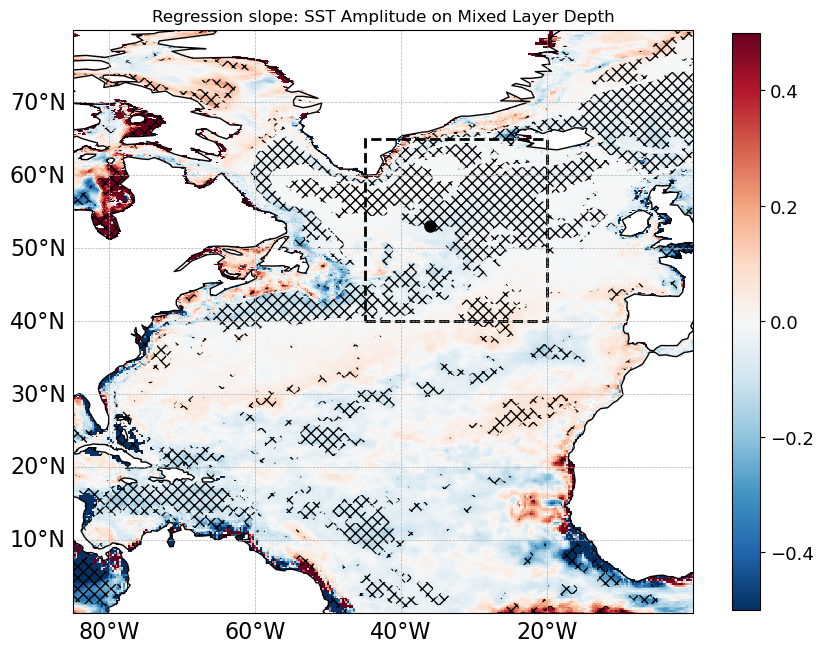

In [16]:
## Start from here in future 

r_da = (xr.open_dataset('Amp_MLD_regression.nc'))['correlation']
pval_da = (xr.open_dataset('Amp_MLD_regression_pval.nc'))['p-value']

 
sig_mask = pval_da < 0.05
fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -0.5, vmax = 0.5)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Regression slope: SST Amplitude on Mixed Layer Depth')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

In [ ]:
## CORRELATION COEFFICIENT - MLD and Salinity 

ny, nx = salinity.sizes['j'], salinity.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

print('starting loop')
for y_idx in range (ny):
    for x_idx in range (nx):
        sal_ts = salinity.isel(j=y_idx, i=x_idx)['sos_abs'].values
        MLD_ts = MLD.isel(j=y_idx, i=x_idx)['somxl010'].values
        try:
            r, p = pearsonr(MLD_ts, sal_ts)
            r_data[y_idx, x_idx] = r
            p_data[y_idx, x_idx] = p
        except:
            r_data[y_idx, x_idx] = np.nans
            p_data[y_idx, x_idx] = np.nan
    print(y_idx)

## Converting to dataarray

r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': salinity['j'],
        'i': salinity['i'], 'gphit': (('j', 'i'), salinity['gphit'].values),
        'glamt': (('j', 'i'), salinity['glamt'].values)}, name='correlation',
        attrs={'description': 'Correlation coefficient between MLD and salinity'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': salinity['j'],
        'i': salinity['i'], 'gphit': (('j', 'i'), salinity['gphit'].values),
        'glamt': (('j', 'i'), salinity['glamt'].values)}, name='p-value',
        attrs={'description': 'P-value for correlation coefficient between MLD and salinity'})

## Saving correlation coefficient and p-value 

r_da.to_netcdf('MLD_Sal_pearsons.nc')
pval_da.to_netcdf('MLD_Sal_pearsons_pval.nc')

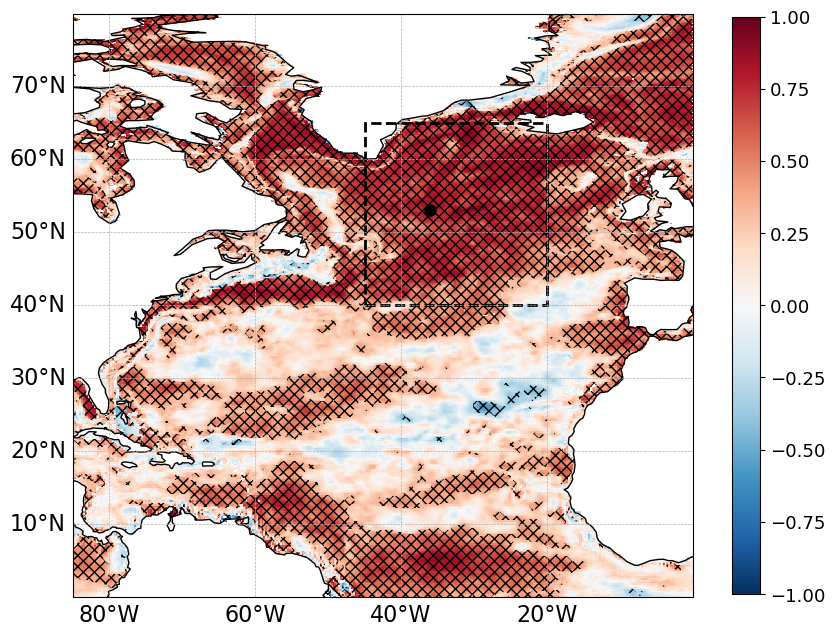

In [17]:
## Start from here in future 

r_da = (xr.open_dataset('MLD_Sal_pearsons.nc'))['correlation']
pval_da = (xr.open_dataset('MLD_Sal_pearsons_pval.nc'))['p-value']

sig_mask = pval_da < 0.05
fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -1, vmax = 1)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
# title = ax.set_title('Pearsons correlation coefficient: MLD and Salinity')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

In [ ]:
## REGRESSION COEFFICIENT - MLD and Salinity  

ny, nx = salinity.sizes['j'], salinity.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

print('starting loop')
for y_idx in range (ny):
    for x_idx in range (nx):
        sal_ts = salinity.isel(j=y_idx, i=x_idx)['sos_abs'].values
        MLD_ts = MLD.isel(j=y_idx, i=x_idx)['somxl010'].values
        if np.isnan(sal_ts).all():
            continue
        results = linregress(sal_ts, MLD_ts) 
        r_data[y_idx, x_idx] = results.slope
        p_data[y_idx, x_idx] = results.pvalue
    print(y_idx)

## Converting to dataarray

r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': salinity['j'],
        'i': salinity['i'], 'gphit': (('j', 'i'), salinity['gphit'].values),
        'glamt': (('j', 'i'), salinity['glamt'].values)}, name='correlation',
        attrs={'description': 'Slope of regression of MLD on salinity'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': salinity['j'],
        'i': salinity['i'], 'gphit': (('j', 'i'), salinity['gphit'].values),
        'glamt': (('j', 'i'), salinity['glamt'].values)}, name='p-value',
        attrs={'description': 'P-value for slope of regression of MLD on salinity'})

## Saving coefficient and p-value 

r_da.to_netcdf('MLD_sal_regression.nc')
pval_da.to_netcdf('MLD_sal_regression_pval.nc')

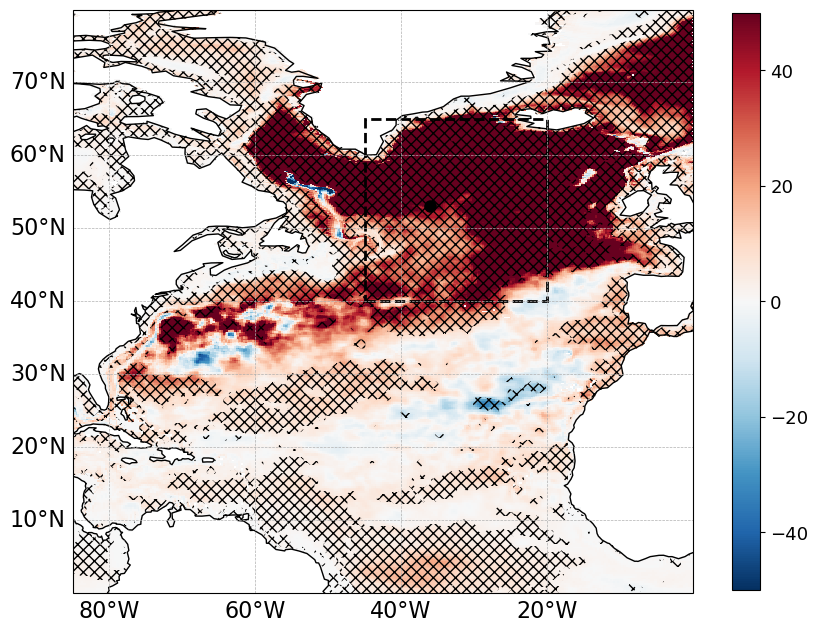

In [18]:
## Start from here in future 

r_da = (xr.open_dataset('MLD_sal_regression.nc'))['correlation']
pval_da = (xr.open_dataset('MLD_sal_regression_pval.nc'))['p-value']

 
sig_mask = pval_da < 0.05
fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -50, vmax = 50)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
# title = ax.set_title('Regression slope: mixed layer depth on salinity')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)